# 44 - FCNN conf60 7-class

**Dataset:** Front-only conf60 (confidence >= 60%)
**Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionFCNN
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly_conf60" / "7class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 7
EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

print(f"Dataset: {DATASET_DIR}")
print(f"Dataset Aug: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU: Tesla T4
Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60
Dataset Aug: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class


In [2]:
def load_dataloaders(dataset_dir, batch_size=32):
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = EmotionLandmarkDataset(dataset_dir / f"X_{split}_landmarks.npy", dataset_dir / f"y_{split}.npy")
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split=="train"), num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(y)} | Val: {len(np.load(dataset_dir / 'y_val.npy'))} | Test: {len(np.load(dataset_dir / 'y_test.npy'))}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return loaders["train"], loaders["val"], loaders["test"]

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 5287 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 27
     fearful: 2
   disgusted: 13
   surprised: 16


## Training B1, B2, B3


Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.5734     0.5192     1.2719    0.8152   0.1283   0.000100  (1.1s)


     2      0.9241     0.8468     0.9384    0.8238   0.1291   0.000100  (0.9s)


     3      0.6873     0.8553     0.7578    0.8238   0.1291   0.000100  (1.0s)


     4      0.5842     0.8574     0.6951    0.8204   0.1288   0.000100  (0.9s)


...

    22      0.3787     0.8786     0.7845    0.8377   0.2076   0.000050  (1.0s)


    23      0.3667     0.8772     0.6270    0.8359   0.2148   0.000050  (0.9s)


    24      0.3752     0.8772     0.6579    0.8359   0.2043   0.000050  (0.9s)


    25      0.3648     0.8812     0.6905    0.8342   0.2384   0.000050  (0.9s)


    26      0.3732     0.8803     0.6245    0.8411   0.2487   0.000050  (0.9s)

Early stopping at epoch 26. Best epoch: 11 (val_f1=0.2659)

Best: epoch 11, val_acc=0.8256, val_f1=0.2659
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/fcnn_b1.pth


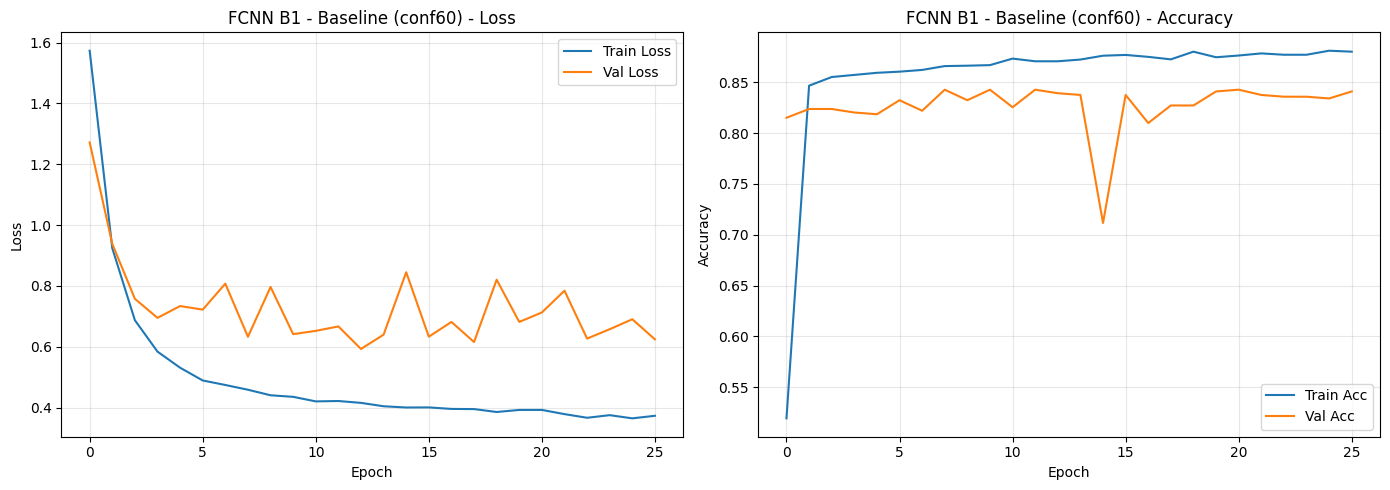

Test Loss: 0.6042
Test Accuracy: 0.7675
Test Macro F1: 0.2317
Test Weighted F1: 0.7650

Classification Report:
              precision    recall  f1-score   support

     neutral       0.91      0.80      0.85       688
       happy       0.52      0.89      0.66       183
         sad       0.21      0.08      0.12        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.77       929
   macro avg       0.23      0.25      0.23       929
weighted avg       0.79      0.77      0.76       929



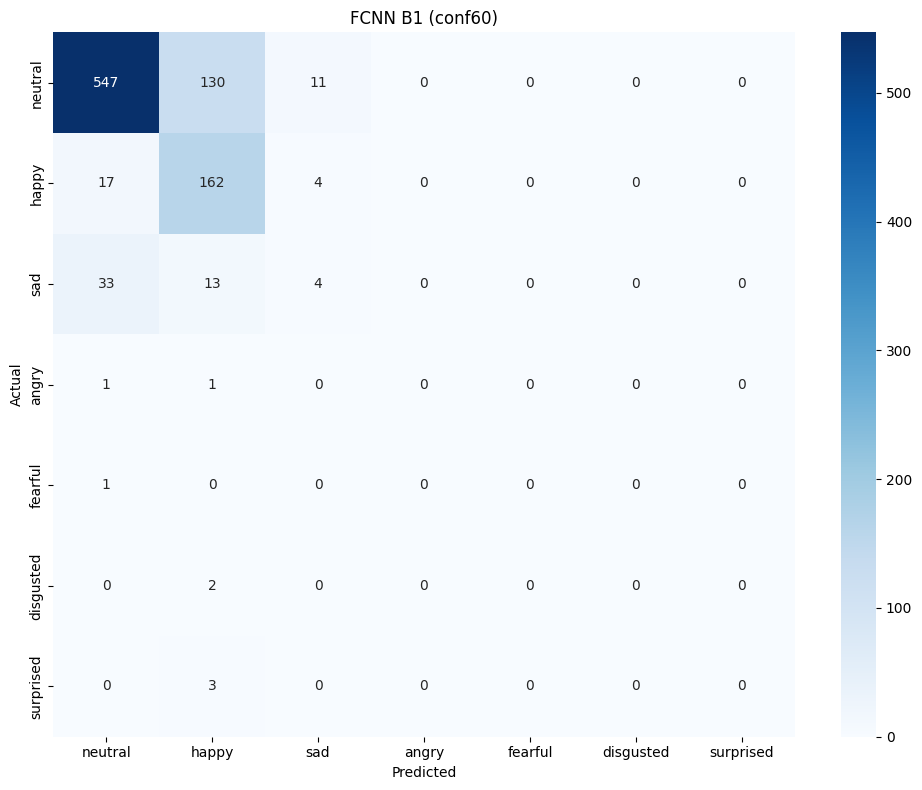

B1: Acc=0.7675 F1=0.2317

Class weights: None
Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.4769     0.5814     1.4168    0.8169   0.1287   0.000100  (0.9s)


     2      0.8746     0.8500     0.9417    0.8238   0.1291   0.000100  (0.9s)


     3      0.6621     0.8553     0.7894    0.8238   0.1291   0.000100  (0.9s)


     4      0.5845     0.8563     0.7686    0.8290   0.1602   0.000100  (0.9s)


...

    46      0.3513     0.8839     0.8796    0.8394   0.1887   0.000050  (1.0s)


    47      0.3412     0.8865     0.7232    0.8394   0.2030   0.000025  (1.0s)


    48      0.3503     0.8825     0.6688    0.8377   0.2326   0.000025  (0.9s)


    49      0.3465     0.8852     0.7938    0.8428   0.2042   0.000025  (0.9s)


    50      0.3488     0.8831     0.6384    0.8446   0.2605   0.000025  (1.0s)

Best: epoch 37, val_acc=0.8377, val_f1=0.2671
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/fcnn_b2.pth


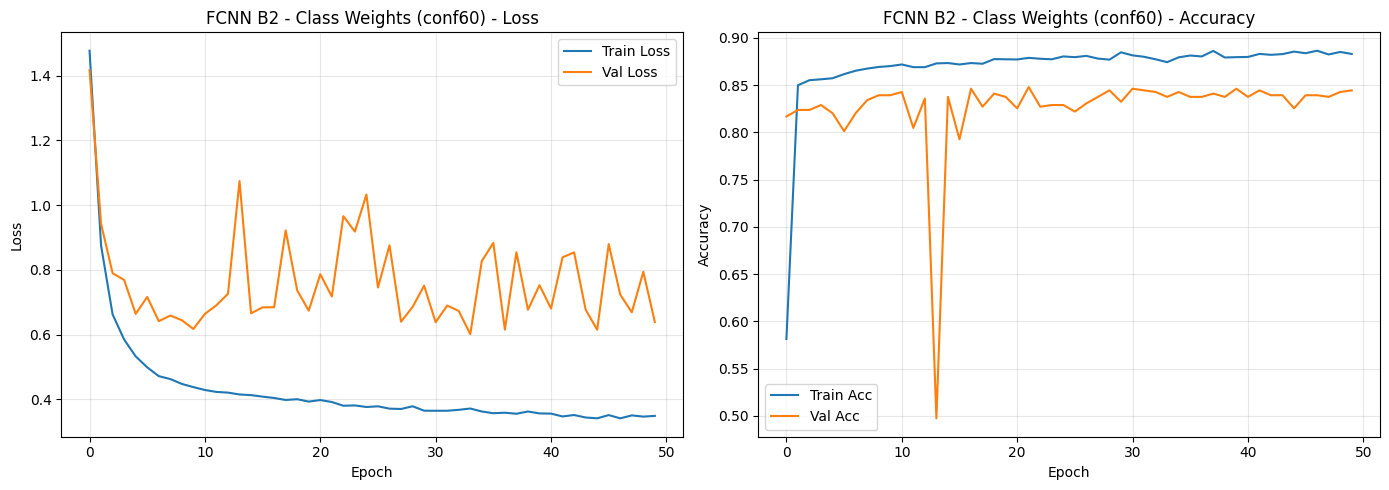

Test Loss: 0.5737
Test Accuracy: 0.7653
Test Macro F1: 0.2437
Test Weighted F1: 0.7674

Classification Report:
              precision    recall  f1-score   support

     neutral       0.89      0.80      0.85       688
       happy       0.56      0.83      0.67       183
         sad       0.21      0.18      0.20        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.77       929
   macro avg       0.24      0.26      0.24       929
weighted avg       0.78      0.77      0.77       929



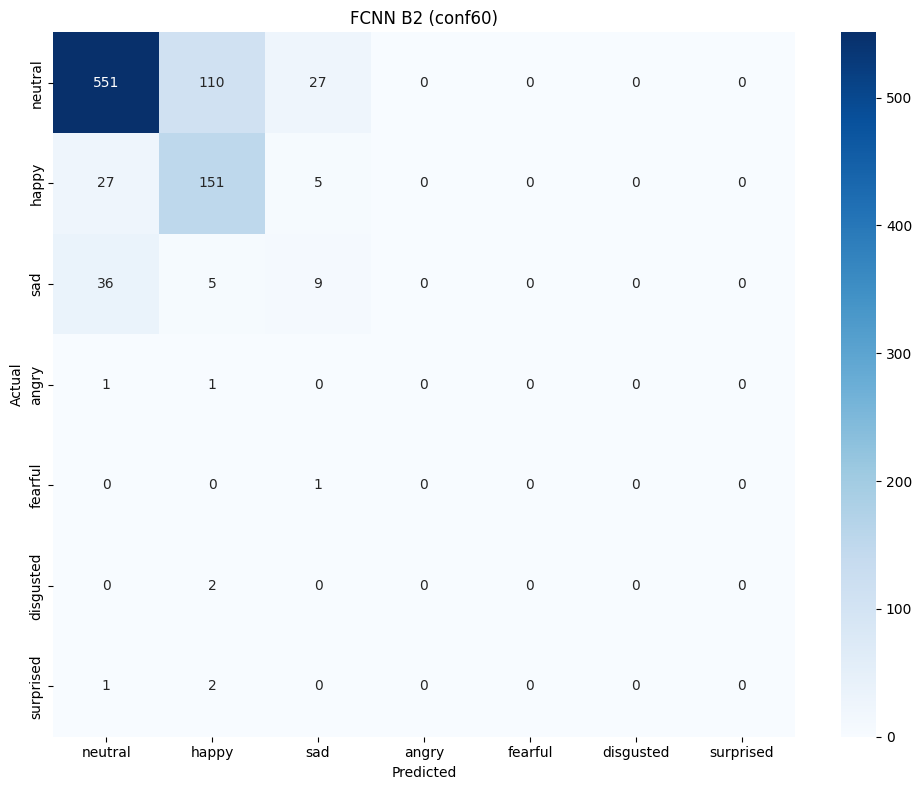

B2: Acc=0.7653 F1=0.2437
Train: 5829 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150

Training B3 (class weights + augmented)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.7477     0.4356     1.2812    0.8135   0.1282   0.000100  (1.0s)


     2      1.1402     0.7581     0.9162    0.8169   0.1285   0.000100  (1.0s)


     3      0.9210     0.7739     0.7909    0.8238   0.1291   0.000100  (1.1s)


     4      0.8191     0.7797     0.7324    0.8204   0.1288   0.000100  (1.0s)


...

    26      0.5361     0.8183     0.7508    0.8342   0.1875   0.000050  (1.0s)


    27      0.5348     0.8269     0.6341    0.8428   0.2380   0.000050  (1.0s)


    28      0.5323     0.8221     0.8168    0.8325   0.1842   0.000050  (1.0s)


    29      0.5133     0.8296     0.7286    0.8394   0.1940   0.000050  (1.0s)


    30      0.5122     0.8305     0.6875    0.8394   0.2032   0.000050  (1.0s)

Early stopping at epoch 30. Best epoch: 15 (val_f1=0.2690)

Best: epoch 15, val_acc=0.8515, val_f1=0.2690
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/fcnn_b3.pth


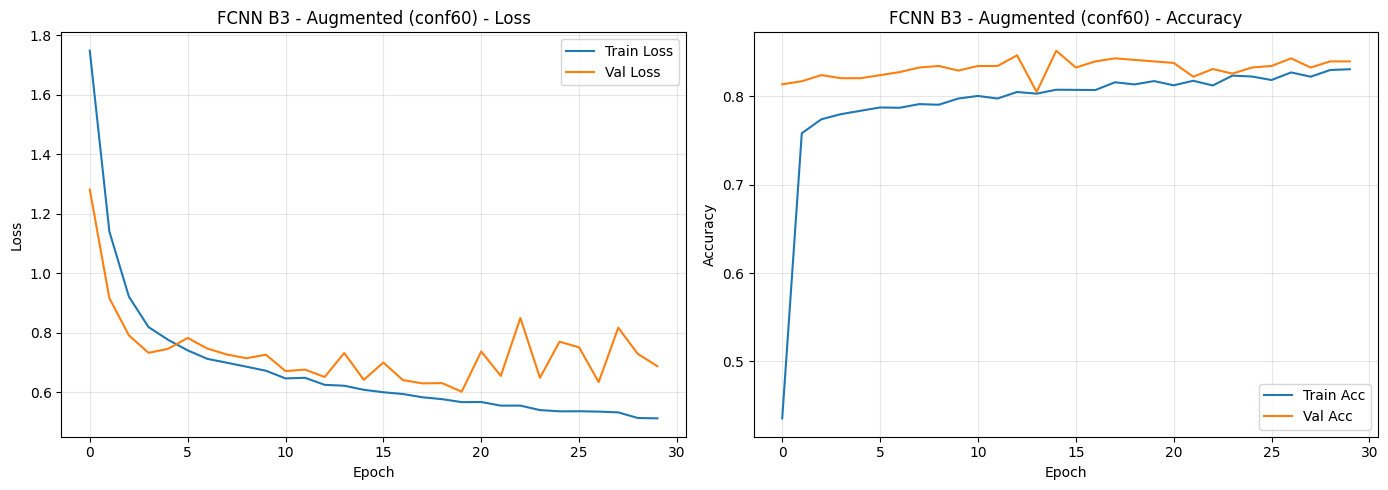

Test Loss: 0.6700
Test Accuracy: 0.7395
Test Macro F1: 0.2224
Test Weighted F1: 0.7580

Classification Report:
              precision    recall  f1-score   support

     neutral       0.86      0.87      0.86       688
       happy       0.84      0.44      0.58       183
         sad       0.08      0.20      0.12        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.74       929
   macro avg       0.25      0.22      0.22       929
weighted avg       0.80      0.74      0.76       929



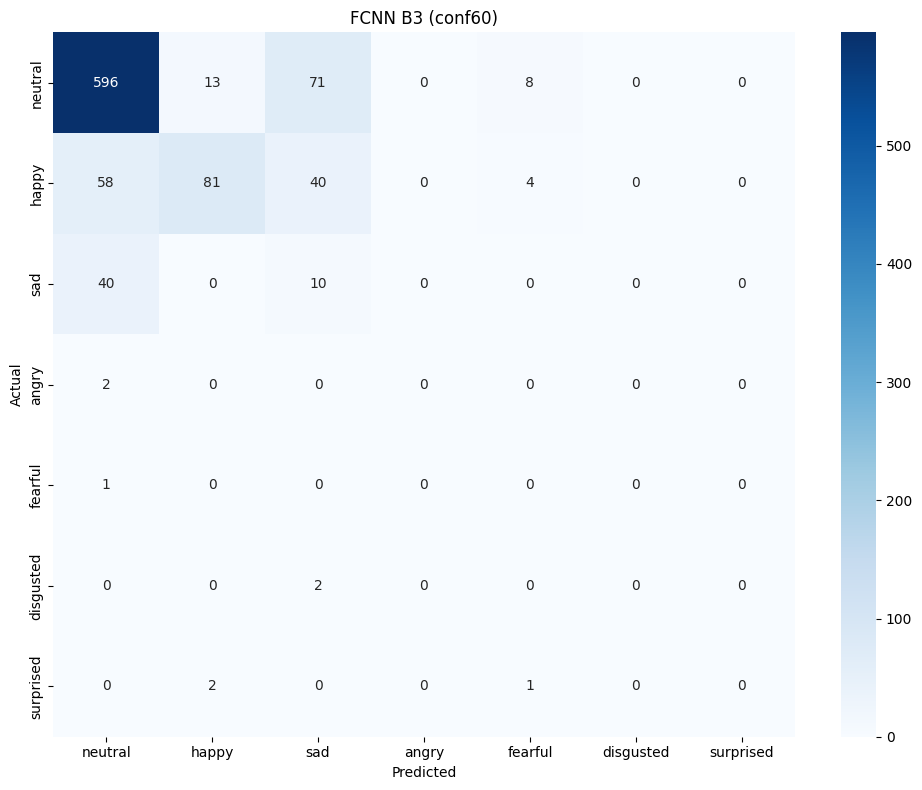

B3: Acc=0.7395 F1=0.2224

RINGKASAN FCNN (conf60)
  B1 Baseline               Acc=0.7675 F1=0.2317
  B2 Class Weights          Acc=0.7653 F1=0.2437
  B3 Weights+Aug            Acc=0.7395 F1=0.2224

Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/fcnn_results.json


In [3]:
all_results = {}

# B1: Baseline
model_b1 = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B1 (baseline)...")
history_b1, _ = train_model(model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "fcnn_b1.pth"))
plot_training_history(history_b1, "FCNN B1 - Baseline (conf60)")
model_b1.load_state_dict(torch.load(OUTPUT_DIR / "fcnn_b1.pth", map_location=device, weights_only=True))
r_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fcnn", EMOTIONS)
plot_confusion_matrix(r_b1["confusion_matrix"], "FCNN B1 (conf60)", EMOTIONS)
all_results["B1 Baseline"] = {"accuracy": float(r_b1["test_accuracy"]), "macro_f1": float(r_b1["test_macro_f1"]), "weighted_f1": float(r_b1["test_weighted_f1"])}
print(f"B1: Acc={r_b1['test_accuracy']:.4f} F1={r_b1['test_macro_f1']:.4f}")

# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"\nClass weights: {weights}")
model_b2 = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("Training B2 (class weights)...")
history_b2, _ = train_model(model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "fcnn_b2.pth"))
plot_training_history(history_b2, "FCNN B2 - Class Weights (conf60)")
model_b2.load_state_dict(torch.load(OUTPUT_DIR / "fcnn_b2.pth", map_location=device, weights_only=True))
r_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fcnn", EMOTIONS)
plot_confusion_matrix(r_b2["confusion_matrix"], "FCNN B2 (conf60)", EMOTIONS)
all_results["B2 Class Weights"] = {"accuracy": float(r_b2["test_accuracy"]), "macro_f1": float(r_b2["test_macro_f1"]), "weighted_f1": float(r_b2["test_weighted_f1"])}
print(f"B2: Acc={r_b2['test_accuracy']:.4f} F1={r_b2['test_macro_f1']:.4f}")

# B3: Class Weights + Augmented
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
model_b3 = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B3 (class weights + augmented)...")
history_b3, _ = train_model(model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "fcnn_b3.pth"))
plot_training_history(history_b3, "FCNN B3 - Augmented (conf60)")
model_b3.load_state_dict(torch.load(OUTPUT_DIR / "fcnn_b3.pth", map_location=device, weights_only=True))
r_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fcnn", EMOTIONS)
plot_confusion_matrix(r_b3["confusion_matrix"], "FCNN B3 (conf60)", EMOTIONS)
all_results["B3 Weights+Aug"] = {"accuracy": float(r_b3["test_accuracy"]), "macro_f1": float(r_b3["test_macro_f1"]), "weighted_f1": float(r_b3["test_weighted_f1"])}
print(f"B3: Acc={r_b3['test_accuracy']:.4f} F1={r_b3['test_macro_f1']:.4f}")

# Summary
print("\n" + "=" * 60)
print("RINGKASAN FCNN (conf60)")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<25} Acc={r['accuracy']:.4f} F1={r['macro_f1']:.4f}")

with open(OUTPUT_DIR / "fcnn_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {OUTPUT_DIR / 'fcnn_results.json'}")